### Hyperparameterparameter Optimization for Machine Learning

This notebook provides code to perform hyperparameter optimization (also known as hyperparameter tuning) using the Optuna package.<br>
More information on Optuna can be found in: <br>
https://optuna.org/<br>
https://optuna.readthedocs.io/en/stable/index.html<br>
https://github.com/optuna/optuna<br>

The machine learning post-processing correction model tuned in this notebook is designed to improve retrospective streamflow simulations from the National Water Model (NWM) Version 3.0 using LightGBM. As a test case, the tuning process is demonstrated at the Otter Creek at Middlebury, VT site, which has the following characteristics:<br>
* USGS site number: 04282500
* NHDPlus comid: 22220605
* Drainage area: 1,626.51 km2

This example uses two searching algorithms, Random Search and CMA-ES (Covariance Matrix Adaptation Evolution Strategy), to illustrate practical applications of Optuna for a single-site model.
* Training and hyperparameter tuning period: up to 2018-01-01 00:00:00
* Testing period: after 2018-01-01 00:00:00 

The 44-year retrospective simulation from NWM v3.0 (February 1979 – January 2023) is publicly available at: https://registry.opendata.aws/nwm-archive/


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
sns.set_context("talk")

# Libraries to apply LightGBM
import lightgbm
from lightgbm import LGBMRegressor
from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import make_scorer, mean_squared_error
from scipy.stats import pearsonr
set_config(transform_output="pandas") 

# Libraries for hyperparameter tunning
import optuna
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.model_selection import TimeSeriesSplit


In [2]:
# Reading input dataset
dataPath = '../../input-data/hyperparameter-tuning/'
Path = "../../output-data/hyperparameter-tuning/"

# Load data:
input_features = pd.read_parquet(f'{dataPath}ml_db_wWL.parquet', engine='pyarrow') 

In [3]:
#---------------------------------
# Select the siteID to work with
#---------------------------------
input_features['siteID'].unique()
site = '04282500'
df_ml = input_features.loc[input_features['siteID'] == site]

df_ml['siteID'].unique()

#----------------------------------
# Filter dataset if needed
#----------------------------------
# Features to drop
to_drop = ["q_nwm_lag_3H",'nwm_precip_window_8_sum','nwm_precip_window_23_sum']
df_ml = df_ml.drop(columns=to_drop)
            
# Double check column names or features
print('Input variables:')
print(list(df_ml.columns.values))
# Sanity check: data span.
print('Data span:')
print(df_ml.index.min(), df_ml.index.max())

# Create a directory to save the results if it doesn't exist already
savePath = Path + site
if not os.path.exists(savePath):
    os.makedirs(savePath)

Input variables:
['siteID', 'q_nwm', 'q_obs', 'nwm_precip', 'nwm_precip_window_8_mean', 'nwm_precip_window_23_mean', 'q_nwm_window_4_mean', 'q_nwm_window_8_mean', 'q_nwm_window_24_mean', 'q_nwm_lag_1H', 'Pobs_lag_24', 'snowDepth_lag_24', 'tmax_lag_24', 'tmin_lag_24', 'tmin_c', 'Basin_area', 'TOT_STREAM_SLOPE', 'TOT_STREAM_LENGTH', 'month', 'day', 'wl_obs_lag_4H', 'wl_obs_lag_6H', 'wl_obs_lag_8H']
Data span:
1979-02-01 00:00:00 2023-02-01 00:00:00


In [4]:
#-----------------------------------------
# PREPARE ML MODEL
#-----------------------------------------
# Define our target value
target = ["q_obs"]

# Rescale our features and put into a pipeline. 
# This pipeline could be extended to include the creation of new features
pipeline = make_pipeline(MinMaxScaler())

# Let's see the pipeline to double-check
#pipeline

# Let's check how our feature engineering pipeline behaves
#pipeline.fit_transform(df_ml)
# We can use `clone` to return an unfitted version
# of the pipeline.
#pipeline = clone(pipeline)

#----------------------------
# --- CONFIG --- #
# Define time of first prediction, this determines our train / test split
forecast_start_time = pd.to_datetime("2018-01-01 00:00:00")
        
# --- CREATE TRAINING & TESTING DATAFRAME  --- #
# Ensure we only have training data up to the start
# of the forecast.
df_train = df_ml.loc[df_ml.index < forecast_start_time].copy()
df_train = df_train.drop(columns=['siteID'])
df_train_bckup = df_ml.loc[df_ml.index < forecast_start_time].copy()

df_test = df_ml.loc[df_ml.index >= forecast_start_time].copy()
df_test = df_test.drop(columns=['siteID'])
df_test_bckup = df_ml.loc[df_ml.index >= forecast_start_time].copy()

# Create X_train and y_train
X_train = pipeline.fit_transform(df_train.dropna()).drop(columns=["q_obs"])
y_train = df_train.dropna()[target]

In [5]:
# Let's deifine an empty list to store the results
df_results = []

In [6]:
#------------------------------------
# Define case for tunning
#------------------------------------
case = 'OptunaRs'#'CmaEs'

# Score to use during tuning
score_dict = {
    "OptunaRs": 'neg_root_mean_squared_error', #'r2'
    "CmaEs": 'neg_root_mean_squared_error', #'r2'
    }

# Number of trials
trials_dict = {
    "OptunaRs": 200,
    "CmaEs": 200,
    }

[I 2025-05-25 19:01:37,001] A new study created in memory with name: no-name-ce68de06-1e25-41b7-952c-82a6224b4578


Seed value: 51


  0%|          | 0/200 [00:00<?, ?it/s]

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=47, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=47
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=47, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=47
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=47, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=47
[I 2025-05-25 19:01:38,387] Trial 0 finished with value: -3.879064929707473 and parameters: {'lgbm_n_estimators': 438, 'lgbm_num_leaves': 10, 'lgbm_min_data_in_leaf': 47, 'lgbm_max_depth': 6}. Best is trial 0 with value: -3.879064929707473.
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be

C:\Users\mmorale3\AppData\Local\Temp\ipykernel_26284\1662089388.py:68: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\mmorale3\AppData\Local\Temp\ipykernel_26284\1662089388.py:74: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Figure size 600x400 with 0 Axes>

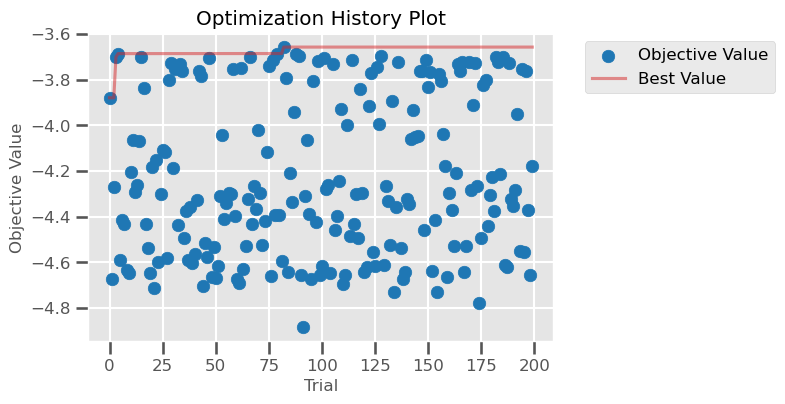

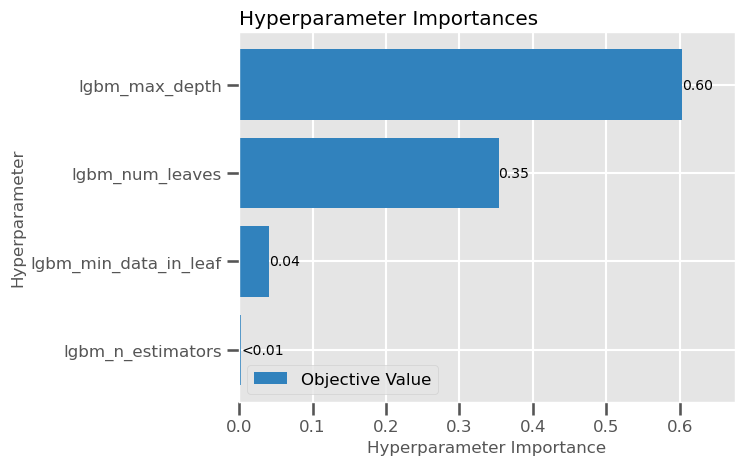

In [7]:
#--------------------------------------------
# Start the tunning
#--------------------------------------------
# Define random seed and sampler
#----------------------------------
seed_value = 51#random.randrange(1,100)

# save this seed somewhere. So if you like the result you can use this seed to reproduce it
print('Seed value:', seed_value)
        
sampler_dict = {
    "OptunaRs":optuna.samplers.RandomSampler(seed = seed_value),
    "CmaEs": optuna.samplers.CmaEsSampler(seed = seed_value),
    } 

#----------------------------------------    
# --- HYPERPARAMETER OPTIMIZATION --- #
#----------------------------------------
# Deine the method to perform cross-validation split for time series
cv_split = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)

# Define the objective function
# the objective function takes the hyperparameter space as input

# Default searching algorithm Tree-structured Parzen Estimator.
def objective(trial):
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 100, 600)
    lgbm_num_leaves = trial.suggest_int('lgbm_num_leaves', 8, 64)
    lgbm_min_data_in_leaf = trial.suggest_int('lgbm_min_data_in_leaf', 20, 100)
    lgbm_max_depth = trial.suggest_int("lgbm_max_depth", 3, 8)
            
    # Define the model.
    model = LGBMRegressor(
        boosting = "gbdt",
        linear_tree=True, 
        linear_lambda=0.1, 
        importance_type='split',
        n_estimators=lgbm_n_estimators,
        num_leaves = lgbm_num_leaves,
        min_data_in_leaf = lgbm_min_data_in_leaf,
        max_depth = lgbm_max_depth,
        )

    score = cross_val_score(model, X_train, y_train, cv=cv_split,scoring=score_dict[case])
    accuracy = score.mean()
    return accuracy

# Define the search
study = optuna.create_study(
    direction="maximize",
    sampler=sampler_dict[case],
    )

study.optimize(objective, n_trials=trials_dict[case],show_progress_bar=True)
        
# Let's plot some results        
plt.rcParams.update({
    'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
        })

# Optimization history
figure = plt.gcf()
figure.set_size_inches(6, 4)
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.savefig(f'{savePath}/Optuna_optimizationHistory_{case}_{site}.png',dpi=(100), bbox_inches='tight')

# Parameter importance
figure = plt.gcf()
figure.set_size_inches(6, 4)
optuna.visualization.matplotlib.plot_param_importances(study)
plt.savefig(f'{savePath}/Optuna_paramImportance_{case}_{site}.png',dpi=(100), bbox_inches='tight')

# Print best params and score value
best_params = study.best_params
best_value = study.best_value

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=54, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=54


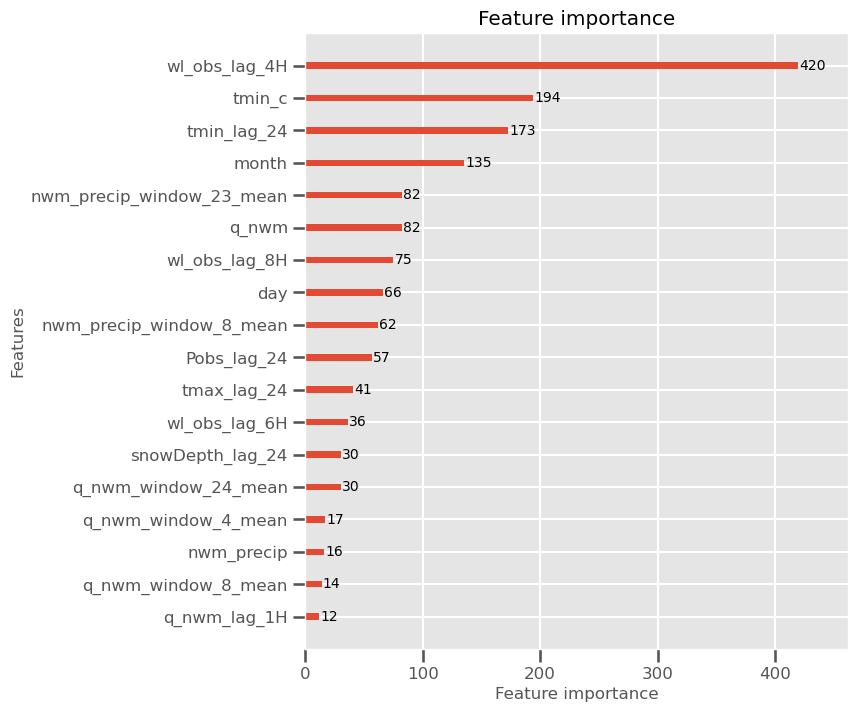

In [8]:
#---------------------------------------------------------
# Re-train and run the model with the best parameters
#---------------------------------------------------------
best_n_estimators = best_params['lgbm_n_estimators']
best_num_leaves = best_params['lgbm_num_leaves']
best_min_data_in_leaf = best_params['lgbm_min_data_in_leaf']
best_max_depth = best_params['lgbm_max_depth']
        
best_model = LGBMRegressor(boosting = "gbdt",
                           linear_tree=True, 
                           linear_lambda=0.1, 
                           n_estimators= best_n_estimators,
                           importance_type='split',
                           num_leaves = best_num_leaves,
                           min_data_in_leaf = best_min_data_in_leaf,
                           max_depth = best_max_depth,
                           )
        
# --- MODEL TRAINING---#
best_model.fit(X_train, y_train)
        
#----- PREDICT USING ALL THE TESTING PERIOD----#
X_test = pipeline.transform(df_test.dropna()).drop(columns=["q_obs"])
y_test = df_test.dropna()[target]
# Predict one step ahead.
y_pred = best_model.predict(X_test)
            
# Save the results to postprocess and assess results
#---------------------------------------------------------
df_y_pred = df_test.dropna()[["q_nwm","q_obs"]] 
df_y_pred['y_pred'] = y_pred.tolist()
df_y_pred.to_csv(f'{savePath}/df_y_pred_{case}_.csv') 

# See feature importance
#------------------------
ax = lightgbm.plot_importance(best_model)
figure = plt.gcf()
figure.set_size_inches(7, 8)
plt.savefig(f'{savePath}/FImportance_{case}.png',dpi=(100), bbox_inches='tight')

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=54, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=54
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=54, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=54
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=54, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=54
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt
[LightGBM] [Warning] min_data_in_leaf is set=54, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=54
[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. C

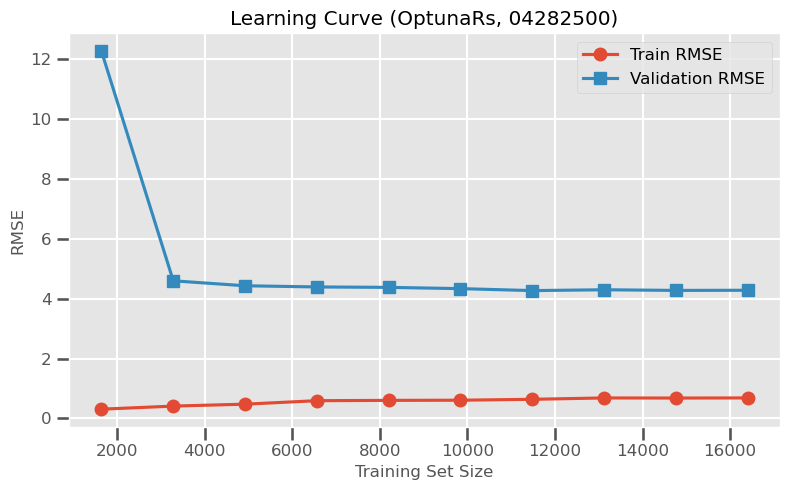

In [10]:
# Define RMSE scorer
scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Generate learning curve
train_sizes, train_scores, valid_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_split,  # Same TimeSeriesSplit used for tuning
    scoring=scorer,
    shuffle=False  # Important for time series
)

# Convert scores to RMSE
train_rmse = np.sqrt(-train_scores.mean(axis=1))
valid_rmse = np.sqrt(-valid_scores.mean(axis=1))

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
plt.plot(train_sizes, valid_rmse, marker='s', label='Validation RMSE')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title(f'Learning Curve ({case}, {site})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'{savePath}/LearningCurve_{case}_{site}.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
#---------------------------------------------------------
# Save the main results in a dataframe
#---------------------------------------------------------
df_results.append({
    'SiteID': site,
    "Case": case,
    "Seed_value": seed_value,
    "n_estimators": best_n_estimators,
    "num_leaves" : best_num_leaves,
    "min_data_in_leaf" : best_min_data_in_leaf,
    "max_depth" : best_max_depth,
    "best_value": best_value,
    })

# Save results in a dataframe        
results = pd.DataFrame(df_results)
results.to_csv(f'{savePath}/hyperParamTuning_summary.csv')      

In [12]:
# Let's run the ML model with default parameters for comparisson
#----------------------------------------------------------------
model = LGBMRegressor(
                      boosting = "gbdt",
                      linear_tree=True, 
                      linear_lambda=0.1, 
                      n_estimators=300,
                      importance_type='split',
                     )

# --- MODEL TRAINING---#
model.fit(X_train, y_train)
#----- PREDICT USING ALL THE TESTING PERIOD----#
y_pred = model.predict(X_test)
# Save the results 
#------------------
df_y_pred['y_pred_default'] = y_pred.tolist()

[LightGBM] [Warning] boosting is set=gbdt, boosting_type=gbdt will be ignored. Current value: boosting=gbdt


In [16]:
# Let's compare the predictions obtained with the default model and the one tuned
#---------------------------------------------------------------------------------
# Define helper functions
def kge(sim, obs):
    r = np.corrcoef(sim, obs)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

def nse(sim, obs):
    return 1 - np.sum((sim - obs) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

def bias_norm(sim, obs):
    return 100 * (np.mean(sim) - np.mean(obs)) / np.mean(obs)

# Compute statistics
results = []

for label, series in {'Q_nwm': 'q_nwm', 'ML': 'y_pred_default', 'ML_tuned': 'y_pred'}.items():
    sim = df_y_pred[series].values
    obs = df_y_pred['q_obs'].values

    stats = {
        'siteID': site,
        'pearsonCor': np.round(pearsonr(obs, sim)[0], 2),
        'Kge': np.round(kge(sim, obs), 2),
        'Nse': np.round(nse(sim, obs), 2),
        'BiasNorm': np.round(bias_norm(sim, obs), 2),
        'Rmse': np.round(np.sqrt(mean_squared_error(obs, sim)), 2),
        'Source': label
    }
    results.append(stats)

df_stats = pd.DataFrame(results)
print("Statistics during testing period")
print(df_stats)

Statistics during testing period
     siteID  pearsonCor   Kge   Nse  BiasNorm   Rmse    Source
0  04282500        0.79  0.79  0.60      1.46  16.17     Q_nwm
1  04282500        0.91  0.90  0.81     -1.77  11.12        ML
2  04282500        0.93  0.82  0.80    -11.73  11.31  ML_tuned


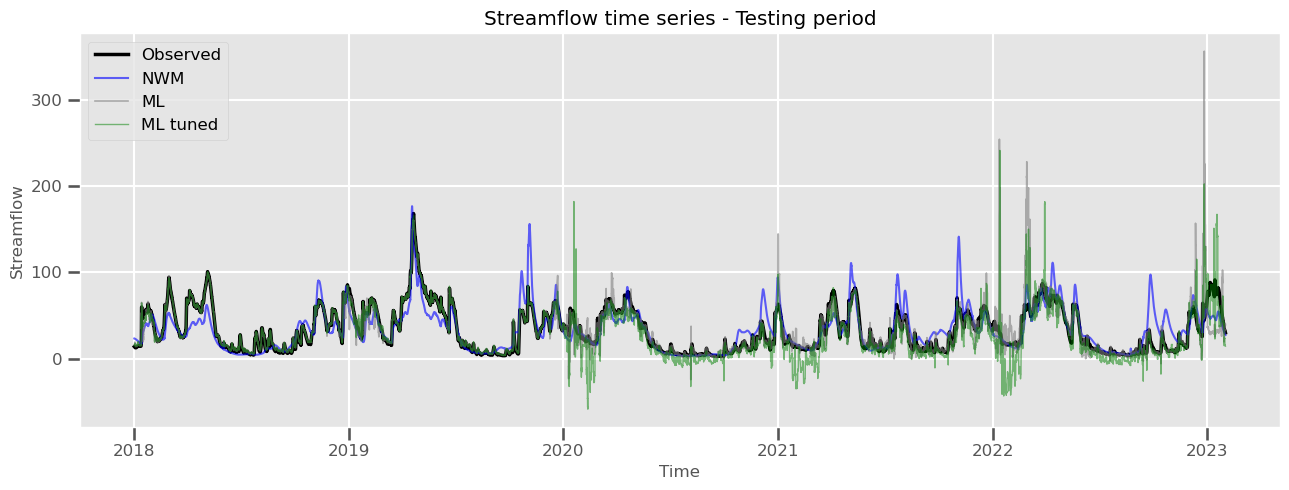

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_y_pred.index, df_y_pred['q_obs'], label='Observed', color='black', linewidth=2.5)
ax.plot(df_y_pred.index, df_y_pred['q_nwm'], label='NWM', color='blue', alpha=0.6, linewidth=1.5)
ax.plot(df_y_pred.index, df_y_pred['y_pred_default'], label='ML', color='gray', alpha=0.6, linewidth=1.2)
ax.plot(df_y_pred.index, df_y_pred['y_pred'], label='ML tuned', color='green', alpha=0.5, linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Streamflow')
ax.set_title('Streamflow time series - Testing period')
ax.legend()
fig.tight_layout()
plt.show()